In [1]:
from src.utils.paths import PROJECT_ROOT, DATA_DIR, EXTERNAL_DATA_DIR, IMAGERY_ROOT, RAW_DATA_DIR

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
IMAGERY_ROOT

'E:\\Datasets\\Imagenes Satelitales\\New York City'

In [2]:
from src import build_dataset

datasets, extents = build_dataset.load_satellite_datasets(year=2014, stretch=False, engine="zarr")

Loading 1 files from /mnt/e/Datasets/Imagenes Satelitales/New York City...


In [7]:
import numpy as np
import geopandas as gpd

def get_test_area_from_file(filename = "Test_NYC_Area.parquet"):
    test = gpd.read_parquet(RAW_DATA_DIR / filename)
    print(test.crs)
    test_polygon = test.dissolve().geometry.iloc[0]
    return test_polygon

def split_train_test_polygon(gdf, test_polygon, buffer=0):
    """
    Splits the GeoDataFrame into 'train' and 'test' based on a test_polygon.
    
    Logic:
    - TEST:  Geometry is strictly INSIDE the test_polygon.
    - TRAIN: Geometry is strictly OUTSIDE the (test_polygon + buffer).
    - DROP:  Geometry overlaps the border or falls within the buffer zone.
    """
    
    # Initialize column with NaNs
    gdf["type"] = np.nan

    # 1. Identify TEST rows
    # "within" checks if the feature is fully contained inside the test polygon
    test_mask = gdf.geometry.within(test_polygon)
    gdf.loc[test_mask, "type"] = "test"

    # 2. Identify TRAIN rows
    # We buffer the test polygon to create the "exclusion zone"
    # "disjoint" checks if the feature has absolutely no overlap with the buffered zone
    exclusion_zone = test_polygon.buffer(buffer)
    train_mask = gdf.geometry.disjoint(exclusion_zone)
    gdf.loc[train_mask, "type"] = "train"

    # 3. Calculate and Print Stats
    test_size = gdf[gdf["type"] == "test"].shape[0]
    train_size = gdf[gdf["type"] == "train"].shape[0]
    invalid_size = gdf[gdf["type"].isna()].shape[0]
    total_size = gdf.shape[0]

    print(
        "",
        f"Size of test dataset: {test_size/total_size*100:.2f}% ({test_size} features)",
        f"Size of train dataset: {train_size/total_size*100:.2f}% ({train_size} features)",
        f"Deleted images due to train/test overlapping: {invalid_size/total_size*100:.2f}% ({invalid_size} features)",
        sep="\n",
    )

    return gdf

gdf = build_dataset.load_income_dataset(variable="avg_hh_inc", trim=False)
test_polygon = get_test_area_from_file()
split_train_test_polygon(gdf, test_polygon, buffer=500)

{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "BoundCRS", "source_crs": {"type": "ProjectedCRS", "name": "unknown", "base_crs": {"name": "unknown", "datum": {"type": "GeodeticReferenceFrame", "name": "Unknown based on GRS 1980 ellipsoid using towgs84=0,0,0,0,0,0,0", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101, "id": {"authority": "EPSG", "code": 7019}}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": "degree"}, {"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": "degree"}]}}, "conversion": {"name": "unknown", "method": {"name": "Lambert Conic Conformal (2SP)", "id": {"authority": "EPSG", "code": 9802}}, "parameters": [{"name": "Latitude of false origin", "value": 40.1666666666667, "unit": "degree", "id": {"authority": "EPSG", "code": 8821}}, {"name": "Longitude of false origin", "value": -74, "unit": 

/tmp/ipykernel_25278/3844879608.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'test' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf.loc[test_mask, "type"] = "test"



Size of test dataset: 23.94% (107673 features)
Size of train dataset: 73.13% (328875 features)
Deleted images due to train/test overlapping: 2.93% (13179 features)


,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,var,type
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1067053.173 209139.295, 1067044.762 ...",0.903605,train
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066993.434 211949.564, 1067030.554 ...",0.903605,train
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066744.615 209584.918, 1066783.937 ...",0.903605,train
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066671.441 209426.912, 1066706.044 ...",0.903605,train
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,"POLYGON ((1066621.379 208092.188, 1066602.7 20...",0.317018,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457302,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914278.373 123196.517, 914236.906 12...",1.036937,train
457303,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914230.566 124269.59, 914264.523 124...",1.036937,train
457304,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914203.412 124013.548, 914200.86 123...",1.036937,train
457305,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((913923.046 124090.499, 913924.229 12...",1.036937,train


In [5]:
test_polygon.crs

AttributeError: 'MultiPolygon' object has no attribute 'crs'

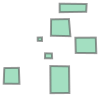